# GramSci - Modello Encoder-Only

**Task:** Rilevamento dell'hate speech in tweet politici italiani (PolicyCorpusXL)  
**Dataset:** HaSpeeDe3 @ EVALITA 2023  
**Modello:** UmBERTo (`Musixmatch/umberto-commoncrawl-cased-v1`) + feature contestuali  
**Metrica:** Media di F1-score sulle due classi  
**Repository:** [therestar/HaSpeeDe3-reloaded](https://github.com/therestar/HaSpeeDe3-reloaded.git)

$$F1_{avg} = \frac{F1_{HS} + F1_{\neg HS}}{2}$$

---

## Struttura del notebook
1. Setup e dipendenze
2. Caricamento e merge dei dataset
3. Analisi Esplorativa (EDA)
4. Pre-processing testuale e contestuale
5. Split Train / Validation
6. Data Augmentation (solo su train split)
7. Dataset PyTorch e DataLoader
8. Architettura del modello
9. Training con early stopping
10. Ottimizzazione della threshold
11. Valutazione finale sul test set
12. Generazione predizioni e analisi degli errori


## 1. Setup e installazione dipendenze


In [ ]:
!pip install transformers==4.40.0 -q
!pip install datasets emoji scikit-learn -q


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import random
import copy
import emoji
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

# Riproducibilità
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo in uso: {device}')


Dispositivo in uso: cuda


## 2. Caricamento dei dataset

Carico i quattro file CSV e filtro solo i record `training_politics` / `test_politics`
come indicato nelle specifiche del task. Unisco testo e metadati tramite `anonymized_tweet_id`.


In [ ]:
train_text = pd.read_csv('training_textual.csv')
test_text  = pd.read_csv('test_textual_gold.csv')
train_ctx  = pd.read_csv('training_contextual.csv')
test_ctx   = pd.read_csv('test_contextual.csv')

# Filtro il dataset specificato nelle istruzioni del task.
train_ctx = train_ctx[train_ctx['dataset'] == 'training_politics']
test_ctx  = test_ctx[test_ctx['dataset']  == 'test_politics']

# Unisco testo e metadati tramite l'ID anonimizzato del tweet.
train_df = train_text.merge(train_ctx, on='anonymized_tweet_id', suffixes=('', '_ctx'))
test_df  = test_text.merge(test_ctx,  on='anonymized_tweet_id', suffixes=('', '_ctx'))

print(f'Training set: {len(train_df)} campioni')
print(f'Test set:     {len(test_df)} campioni')


Training set: 5600 campioni
Test set:     1400 campioni


## 3. Analisi Esplorativa (EDA)

Analizzo:
- Distribuzione delle classi nel training e nel test (i dati di training sono sbilanciati)
- Lunghezza dei tweet per classe
- Correlazione tra feature contestuali e label

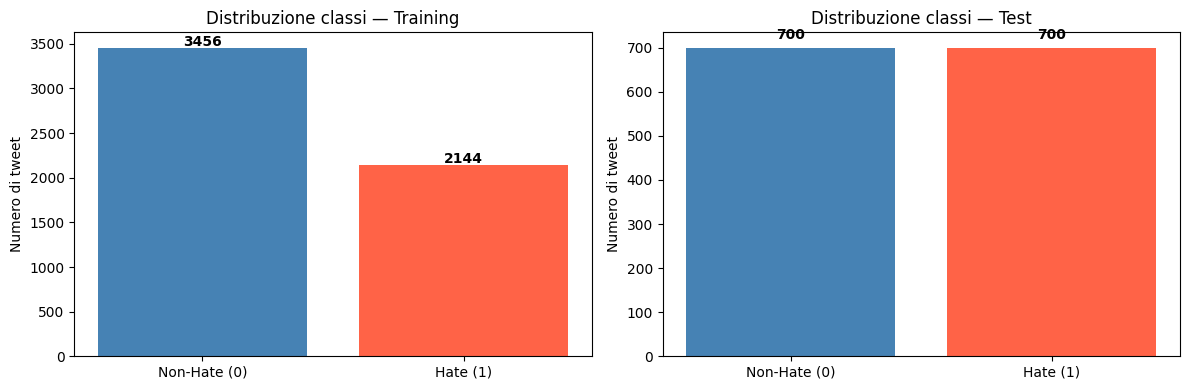

Distribuzione training:
label
0    0.617
1    0.383
Name: proportion, dtype: float64


In [ ]:
# Distribuzione classi
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, df, title in zip(axes, [train_df, test_df], ['Training', 'Test']):
    counts = df['label'].value_counts().sort_index()
    ax.bar(['Non-Hate (0)', 'Hate (1)'], counts.values, color=['steelblue', 'tomato'])
    ax.set_title(f'Distribuzione classi — {title}')
    ax.set_ylabel('Numero di tweet')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print('Distribuzione training:')
print(train_df['label'].value_counts(normalize=True).round(3))


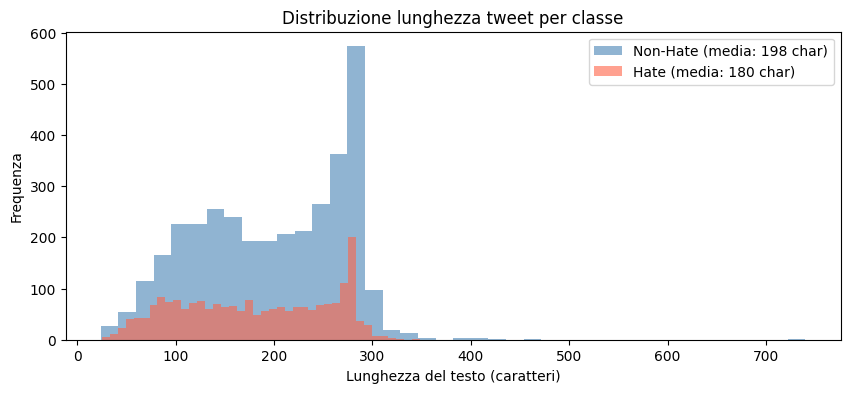

In [ ]:
# Lunghezza tweet per classe
train_df['text_len'] = train_df['anonymized_text'].str.len()

plt.figure(figsize=(10, 4))
for label, color in [(0, 'steelblue'), (1, 'tomato')]:
    subset = train_df[train_df['label'] == label]['text_len']
    plt.hist(subset, bins=40, alpha=0.6, color=color,
             label=f'{"Hate" if label==1 else "Non-Hate"} (media: {subset.mean():.0f} char)')
plt.xlabel('Lunghezza del testo (caratteri)')
plt.ylabel('Frequenza')
plt.title('Distribuzione lunghezza tweet per classe')
plt.legend()
plt.show()


In [ ]:
# Feature contestuali per classe
CTX_FEATURES = ['retweet_count', 'favorite_count', 'is_reply',
                'is_retweet', 'is_quote', 'followers_count',
                'friends_count', 'statuses_count']

print('Media delle feature contestuali per classe:')
print(train_df.groupby('label')[CTX_FEATURES].mean().round(2))


Media delle feature contestuali per classe:
       retweet_count  favorite_count  is_reply  is_retweet  is_quote  \
label                                                                  
0              20.19           73.84      0.19         0.0      0.04   
1              11.65           42.57      0.33         0.0      0.11   

       followers_count  friends_count  statuses_count  
label                                                  
0             17847.85        1817.89       107864.64  
1              3121.16        1743.36        44483.90  


### Osservazione sui dati contestuali

Si nota che i tweet hate sono meno condivisi (retweet) e hanno meno like.
Sono spesso commenti e risposte, hanno gli attributi `is_reply` e `is_quote`,
indicando che spesso sono risposte aggressive ad altri utenti.

## 4. Pre-processing testuale e contestuale

### Cleaning dei dati testuali
- **[URL]**: rimosso perché non informativo
- **Menzioni anonimizzate** (sequenze ≥10 cifre): rimosse
- **Emoji**: convertite in testo descrittivo (tramite `emoji.demojize`), veicolano emozioni rilevanti
- **Hashtag**: rimosso solo il simbolo `#`, mantenuto il testo. Forniscono contesto, ma anche bias.
- **Spazi multipli**: normalizzati

Il pre-processing viene applicato ora, prima dello split, perché è una trasformazione
**deterministica** che non introduce data leakage (non usa statistiche del dataset).


In [ ]:
def preprocess_text(text):
    """
    La pipeline di cleaning fa le seguenti operazioni:
    1. Rimuove placeholder [URL]
    2. Rimuove menzioni anonimizzate (numeri >= 10 cifre)
    3. Converte emoji in testo descrittivo
    4. Rimuove solo il simbolo #, mantiene il testo dell'hashtag
    5. Normalizza spazi multipli
    """
    text = re.sub(r'\[URL\]', '', text)
    text = re.sub(r'\b\d{10,}\b', '', text)
    text = emoji.demojize(text, delimiters=(' ', ' '))
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# Pre-processing su train_df (pre-split) e test_df
train_df['clean_text'] = train_df['anonymized_text'].apply(preprocess_text)
test_df['clean_text']  = test_df['anonymized_text'].apply(preprocess_text)

print('Esempio pre-processing:')
print('Originale:', train_df['anonymized_text'].iloc[0])
print('Pulito:   ', train_df['clean_text'].iloc[0])


Esempio pre-processing:
Originale: @unknown Con tutte le denunce che si sta beccando, Salvini rischia di far aumentare le statistiche dei reati commessi da italiani.
Pulito:    @unknown Con tutte le denunce che si sta beccando, Salvini rischia di far aumentare le statistiche dei reati commessi da italiani.


## 5. Split Train / Validation

Lo split viene eseguito **prima** di effettuare data augmentation.

**L'ordine è importante:**  
Se facessi augmentation prima dello split, varianti quasi identiche dello stesso tweet, ad esempio due parole scambiate, potrebbero finire sia in `train_split` che in `val_split`.
Il modello vedrebbe nei dati di training esempi quasi identici a quelli su cui viene valutato, quindi avrei **data leakage**, da cui conseguono metriche di validazione ottimistiche.

**L' ordine corretto è:**
```
train_df  ->  [split 80/20]  ->  train_split  ->  [augmentation]  ->  train_aug
                            ->  val_split     ->  (mai manipolato fino alla valutazione)
```


In [ ]:
# Split stratificato 80/20 su train_df - PRIMA dell'augmentation
train_split, val_split = train_test_split(
    train_df, test_size=0.2, random_state=SEED, stratify=train_df['label']
)

print(f'Train split (pre-aug): {len(train_split)} campioni '
      f'(Hate: {train_split["label"].sum()}, Non-Hate: {(train_split["label"]==0).sum()})')
print(f'Val split:             {len(val_split)} campioni '
      f'(Hate: {val_split["label"].sum()}, Non-Hate: {(val_split["label"]==0).sum()})')


Train split (pre-aug): 4480 campioni (Hate: 1715, Non-Hate: 2765)
Val split:             1120 campioni (Hate: 429, Non-Hate: 691)


## 6. Data Augmentation

Il training set è sbilanciato, la classe `Non-Hate` è più rappresentata. Applico augmentation **solo su `train_split`** e **solo sulla classe Hate**
per portare le due classi a parità.

### Tecniche usate (text-level, language-agnostic)
- **Random Word Swap**: scambia casualmente una coppia di parole adiacenti
- **Random Word Deletion**: rimuove casualmente una parola con probabilità `p=0.1`

Queste tecniche non richiedono risorse linguistiche esterne e funzionano bene
su testi brevi come i tweet.

> **Nota**: lo `StandardScaler` viene fittato su `train_aug` (training aumentato)
> per garantire che le statistiche di normalizzazione (media, std) siano calcolate
> esclusivamente sui dati di training. Val e test vengono solo trasformati.


In [ ]:
def random_word_swap(text, n=1):
    """Scambia n coppie di parole adiacenti casuali."""
    words = text.split()
    if len(words) < 2:
        return text
    for _ in range(n):
        idx = random.randint(0, len(words) - 2)
        words[idx], words[idx + 1] = words[idx + 1], words[idx]
    return ' '.join(words)


def random_word_deletion(text, p=0.1):
    """Elimina ogni parola con probabilità p. Mantiene almeno 1 parola."""
    words = text.split()
    if len(words) == 1:
        return text
    new_words = [w for w in words if random.random() > p]
    return ' '.join(new_words) if new_words else random.choice(words)


def augment_text(text):
    """Applica casualmente uno dei due metodi di augmentation."""
    if random.random() < 0.5:
        return random_word_swap(text, n=1)
    else:
        return random_word_deletion(text, p=0.1)


# --- Augmentation SOLO su train_split solo su classe Hate ---
random.seed(SEED)
n_hate    = (train_split['label'] == 1).sum()
n_nonhate = (train_split['label'] == 0).sum()
gap       = n_nonhate - n_hate
print(f"Prima dell'augmentation -> Non-Hate: {n_nonhate} | Hate: {n_hate} | Gap: {gap}")

hate_samples = train_split[train_split['label'] == 1].sample(
    n=gap, replace=True, random_state=SEED).copy()
hate_samples['clean_text'] = hate_samples['clean_text'].apply(augment_text)
hate_samples['augmented']  = True

train_split_marked             = train_split.copy()
train_split_marked['augmented'] = False
train_aug = pd.concat([train_split_marked, hate_samples], ignore_index=True).sample(
    frac=1, random_state=SEED).reset_index(drop=True)

print(f"Dopo l'augmentation -> Non-Hate: {(train_aug['label']==0).sum()} | "
      f"Hate: {(train_aug['label']==1).sum()}")
print(f'Totale campioni train: {len(train_aug)}')

# --- Feature contestuali: mediana e scaler fittati su train_aug ---
medians = train_aug[CTX_FEATURES].median()
train_aug[CTX_FEATURES]  = train_aug[CTX_FEATURES].fillna(medians)
val_split[CTX_FEATURES]  = val_split[CTX_FEATURES].fillna(medians)
test_df[CTX_FEATURES]    = test_df[CTX_FEATURES].fillna(medians)

scaler          = StandardScaler()
train_ctx_arr   = scaler.fit_transform(train_aug[CTX_FEATURES])
val_ctx_arr     = scaler.transform(val_split[CTX_FEATURES])
test_ctx_scaled = scaler.transform(test_df[CTX_FEATURES])

print(f'\nFeature contestuali: {CTX_FEATURES}')
print(f'Dimensione vettore contestuale: {len(CTX_FEATURES)}')


Prima dell'augmentation -> Non-Hate: 2765 | Hate: 1715 | Gap: 1050
Dopo l'augmentation -> Non-Hate: 2765 | Hate: 2765
Totale campioni train: 5530

Feature contestuali: ['retweet_count', 'favorite_count', 'is_reply', 'is_retweet', 'is_quote', 'followers_count', 'friends_count', 'statuses_count']
Dimensione vettore contestuale: 8


## 7. Dataset PyTorch e DataLoader

Uso **UmBERTo** (`Musixmatch/umberto-commoncrawl-cased-v1`), un modello BERT-like
addestrato su Wikipedia IT e CommonCrawl italiano, non è contaminato da dataset Hate-speech.
È lo stesso modello usato da BERTicelli, uno dei modelli migliori di HaSpeeDe3 e ciò permette un confronto diretto con i risultati del paper.


In [ ]:
MODEL_NAME = 'Musixmatch/umberto-commoncrawl-cased-v1'
MAX_LEN    = 128  # i tweet raramente superano 128 subword token

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'Modello: {MODEL_NAME}')
print(f'Vocabolario: {tokenizer.vocab_size} token')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Modello: Musixmatch/umberto-commoncrawl-cased-v1
Vocabolario: 32005 token


In [ ]:
class HateSpeechDataset(Dataset):
    """
    Dataset PyTorch che combina testo tokenizzato e feature contestuali.
    """
    def __init__(self, texts, ctx_features, labels, tokenizer, max_len):
        self.texts        = texts
        self.ctx_features = ctx_features
        self.labels       = labels
        self.tokenizer    = tokenizer
        self.max_len      = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'ctx_features':   torch.tensor(self.ctx_features[idx], dtype=torch.float),
            'label':          torch.tensor(self.labels[idx], dtype=torch.float)
        }


BATCH_SIZE = 16

train_dataset = HateSpeechDataset(
    train_aug['clean_text'].tolist(), train_ctx_arr,
    train_aug['label'].tolist(), tokenizer, MAX_LEN)

val_dataset = HateSpeechDataset(
    val_split['clean_text'].tolist(), val_ctx_arr,
    val_split['label'].tolist(), tokenizer, MAX_LEN)

test_dataset = HateSpeechDataset(
    test_df['clean_text'].tolist(), test_ctx_scaled,
    test_df['label'].tolist(), tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Batch train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}')


Batch train: 346 | val: 70 | test: 88


## 8. Architettura del modello

Architettura encoder-only con fusione di embedding testuali e feature contestuali:
1. **UmBERTo** → embedding `[CLS]` di 768 dimensioni (rappresentazione dell'intero tweet)
2. **Proiezione contestuale** → `Linear(8 → 64)` + ReLU + Dropout(0.3)
3. **Concatenazione** → vettore da 832 dimensioni
4. **Classificatore** → `Linear(832 → 128)` → ReLU → `Linear(128 → 1)` (1 logit)
5. **Loss**: `BCEWithLogitsLoss` con **`pos_weight`** (la sigmoid è inclusa nella loss)

### pos_weight
Il parametro `pos_weight` di `BCEWithLogitsLoss` scala la loss sui campioni positivi (Hate):

$$pos\_weight = \frac{N_{\neg HS}}{N_{HS}}$$

Dopo l'augmentation le classi sono quasi bilanciate, quindi `pos_weight ≈ 1`.


In [ ]:
class HateSpeechClassifier(nn.Module):
    """
    Classificatore binario encoder-only.
    Combina CLS embedding di UmBERTo con feature contestuali normalizzate.
    """
    def __init__(self, model_name, n_ctx_features, hidden_size=768, dropout=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.ctx_projection = nn.Sequential(
            nn.Linear(n_ctx_features, 64),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size + 64, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)   # 1 logit, sigmoid applicata dalla loss
        )

    def forward(self, input_ids, attention_mask, ctx_features):
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_emb  = bert_out.last_hidden_state[:, 0, :]   # [B, 768]
        ctx_emb  = self.ctx_projection(ctx_features)      # [B, 64]
        combined = torch.cat([cls_emb, ctx_emb], dim=1)  # [B, 832]
        return self.classifier(combined).squeeze(1)       # [B]


model = HateSpeechClassifier(MODEL_NAME, n_ctx_features=len(CTX_FEATURES)).to(device)
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parametri totali:     {total_params:,}')
print(f'Parametri trainabili: {trainable_params:,}')


Parametri totali:     110,729,281
Parametri trainabili: 110,729,281


## 9. Training con Early Stopping

### Iperparametri
- **LR BERT**: 2e-5 perché il fine-tuning deve essere conservativo
- **LR head**: 1e-3 per il classificatore e la proiezione contestuale
- **Weight decay**: 0.01
- **Warmup**: 10% degli step totali
- **Epoche massime**: 15 (l'early stopping eventualmente lo ferma prima)
- **Patience**: 3 epoche senza miglioramento

Il miglior modello (scelto in base allo score F1 su validation) viene salvato in memoria e ricaricato
per la valutazione finale.


In [ ]:
MAX_EPOCHS = 15
PATIENCE   = 3

# pos_weight calcolato su train_aug (post-augmentation)
n_neg      = (train_aug['label'] == 0).sum()
n_pos      = (train_aug['label'] == 1).sum()
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float).to(device)
print(f'pos_weight = {pos_weight.item():.4f}  (n_neg={n_neg}, n_pos={n_pos})')

# Ottimizzatore con learning rate differenziate per backbone e testa
optimizer = AdamW([
    {'params': model.bert.parameters(),           'lr': 2e-5},
    {'params': model.ctx_projection.parameters(), 'lr': 1e-3},
    {'params': model.classifier.parameters(),     'lr': 1e-3}
], weight_decay=0.01)

total_steps  = len(train_loader) * MAX_EPOCHS
warmup_steps = int(total_steps * 0.1)
scheduler    = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

# BCEWithLogitsLoss con pos_weight — la sigmoid è già inclusa, non va aggiunta nella rete
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)


pos_weight = 1.0000  (n_neg=2765, n_pos=2765)


In [ ]:
def run_epoch(model, loader, optimizer, scheduler, criterion, device, train=True):
    """
    Esegue un'epoca di training o valutazione.
    - train=True:  aggiorna i pesi (gradient step)
    - train=False: solo forward pass (usa no_grad)
    """
    model.train() if train else model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            ctx_feat       = batch['ctx_features'].to(device)
            labels         = batch['label'].to(device)

            if train:
                optimizer.zero_grad()

            logits = model(input_ids, attention_mask, ctx_feat)
            loss   = criterion(logits, labels)

            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()

            total_loss += loss.item()
            # Threshold 0.5 durante il training — solo per monitorare F1
            preds = (torch.sigmoid(logits) >= 0.5).long().cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.long().cpu().numpy())

    avg_loss = total_loss / len(loader)
    f1_avg   = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, f1_avg


In [ ]:
history = {'train_loss': [], 'train_f1': [], 'val_loss': [], 'val_f1': []}
best_val_f1       = 0.0
best_model_wts    = copy.deepcopy(model.state_dict())
epochs_no_improve = 0
best_epoch        = 0

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_f1 = run_epoch(model, train_loader, optimizer, scheduler,
                                     criterion, device, train=True)
    val_loss,   val_f1   = run_epoch(model, val_loader,   None, None,
                                     criterion, device, train=False)

    history['train_loss'].append(train_loss)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)

    improved = '✓' if val_f1 > best_val_f1 else ' '
    print(f'Ep {epoch:02d}/{MAX_EPOCHS} | '
          f'Train Loss: {train_loss:.4f} F1: {train_f1:.4f} | '
          f'Val Loss: {val_loss:.4f} F1: {val_f1:.4f} {improved}')

    if val_f1 > best_val_f1:
        best_val_f1       = val_f1
        best_model_wts    = copy.deepcopy(model.state_dict())
        best_epoch        = epoch
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f'\nEarly stopping alla epoca {epoch} '
                  f'(nessun miglioramento per {PATIENCE} epoche consecutive)')
            break

# Ripristina i pesi del miglior modello
model.load_state_dict(best_model_wts)
print(f'\nMiglior modello: epoca {best_epoch} — Val F1: {best_val_f1:.4f}')


Ep 01/15 | Train Loss: 0.4823 F1: 0.7637 | Val Loss: 0.2754 F1: 0.8942 ✓
Ep 02/15 | Train Loss: 0.2590 F1: 0.9123 | Val Loss: 0.2720 F1: 0.8896  
Ep 03/15 | Train Loss: 0.1647 F1: 0.9512 | Val Loss: 0.3660 F1: 0.8956 ✓
Ep 04/15 | Train Loss: 0.0930 F1: 0.9769 | Val Loss: 0.4878 F1: 0.9003 ✓
Ep 05/15 | Train Loss: 0.0726 F1: 0.9821 | Val Loss: 0.5527 F1: 0.9001  
Ep 06/15 | Train Loss: 0.0366 F1: 0.9913 | Val Loss: 0.6669 F1: 0.8955  
Ep 07/15 | Train Loss: 0.0362 F1: 0.9920 | Val Loss: 0.8874 F1: 0.8813  

Early stopping alla epoca 7 (nessun miglioramento per 3 epoche consecutive)

Miglior modello: epoca 4 — Val F1: 0.9003


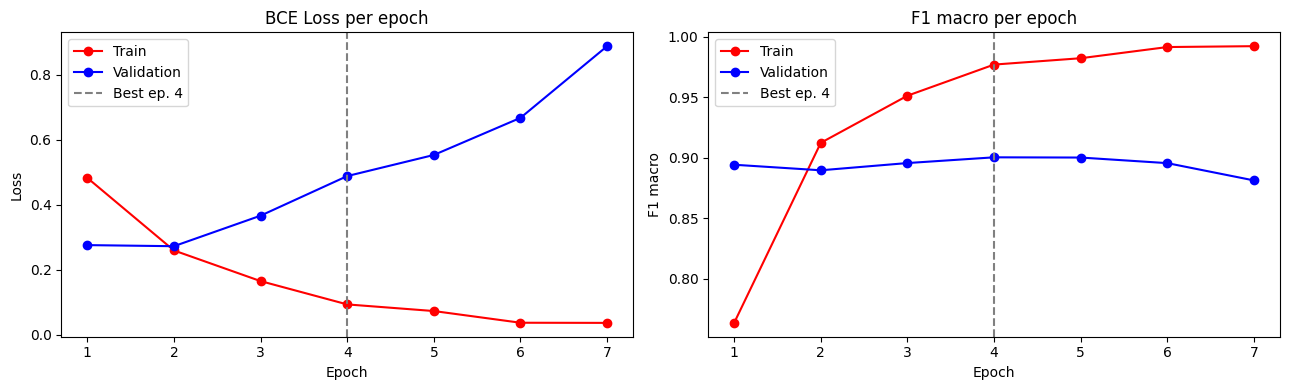

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
epochs_range = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_range, history['train_loss'], 'o-', color='red',    label='Train')
axes[0].plot(epochs_range, history['val_loss'],   'o-', color='blue', label='Validation')
axes[0].axvline(best_epoch, linestyle='--', color='gray', label=f'Best ep. {best_epoch}')
axes[0].set_title('BCE Loss per epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(epochs_range, history['train_f1'], 'o-', color='red',    label='Train')
axes[1].plot(epochs_range, history['val_f1'],   'o-', color='blue', label='Validation')
axes[1].axvline(best_epoch, linestyle='--', color='gray', label=f'Best ep. {best_epoch}')
axes[1].set_title('F1 macro per epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1 macro')
axes[1].legend()

plt.tight_layout()
plt.show()


## 10. Ottimizzazione della Threshold

La threshold di default a 0.5 non è necessariamente ottimale, specialmente con classi
sbilanciate. Effettuo uno **sweep sul validation set** per trovare la threshold
che massimizza F1_avg sulle due classi.


Threshold ottimale: 0.33  →  F1_val = 0.9013
F1_val con threshold 0.50: 0.9003


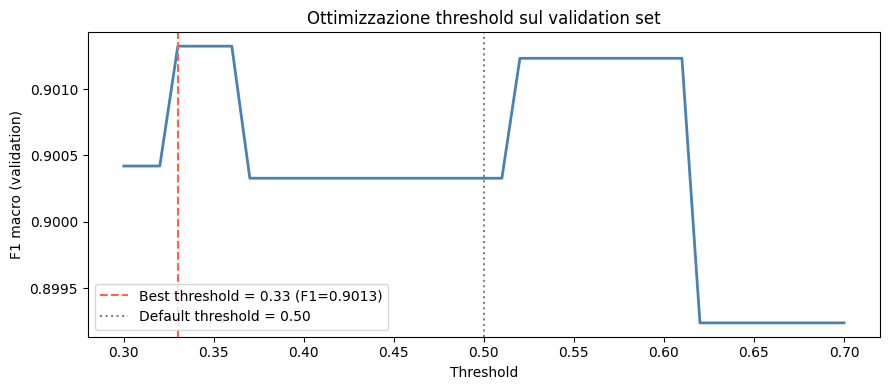

In [ ]:
def get_logits(model, loader, device):
    """Raccoglie le probabilità sigmoid dal modello sull'intero loader."""
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            ctx_feat       = batch['ctx_features'].to(device)
            labels         = batch['label']
            logits = model(input_ids, attention_mask, ctx_feat)
            all_probs.extend(torch.sigmoid(logits).cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_probs), np.array(all_labels)


# Sweep sul validation set
val_probs, val_labels = get_logits(model, val_loader, device)

thresholds = np.arange(0.30, 0.71, 0.01)
f1_scores  = []
for t in thresholds:
    preds = (val_probs >= t).astype(int)
    f1_scores.append(f1_score(val_labels, preds, average='macro', zero_division=0))

best_idx       = np.argmax(f1_scores)
BEST_THRESHOLD = thresholds[best_idx]
best_f1_val    = f1_scores[best_idx]

print(f'Threshold ottimale: {BEST_THRESHOLD:.2f}  →  F1_val = {best_f1_val:.4f}')
print(f'F1_val con threshold 0.50: {f1_scores[np.argmin(np.abs(thresholds - 0.5))]:.4f}')

plt.figure(figsize=(9, 4))
plt.plot(thresholds, f1_scores, color='steelblue', linewidth=2)
plt.axvline(BEST_THRESHOLD, color='tomato', linestyle='--',
            label=f'Best threshold = {BEST_THRESHOLD:.2f} (F1={best_f1_val:.4f})')
plt.axvline(0.5, color='gray', linestyle=':', label='Default threshold = 0.50')
plt.xlabel('Threshold')
plt.ylabel('F1 macro (validation)')
plt.title('Ottimizzazione threshold sul validation set')
plt.legend()
plt.tight_layout()
plt.show()


## 11. Valutazione finale sul Test Set

Utilizzo il miglior modello (pesi dell'epoca con val F1 massima)
con la **threshold ottimizzata** sul validation set.

| Sistema | F1_avg |
|---|---|
| Baseline SVM | 0.8457 |
| CHILab (AlBERTo) | 0.8510 |
| BERTicelli (UmBERTo) | 0.8976 |
| extremITA (IT5 + LLaMA) | 0.9030 |
| Best system (odang4) | 0.9128 |
| Nostro modello (**GramSci**) |  |


In [ ]:
test_probs, test_labels_arr = get_logits(model, test_loader, device)
test_preds = (test_probs >= BEST_THRESHOLD).astype(int)
test_f1    = f1_score(test_labels_arr, test_preds, average='macro', zero_division=0)

print('=' * 55)
print(f'Threshold usata:  {BEST_THRESHOLD:.2f}')
print(f'F1 avg sul test:  {test_f1:.4f}')
print('=' * 55)
print()
print('Report dettagliato:')
print(classification_report(test_labels_arr, test_preds,
                             target_names=['Non-Hate (0)', 'Hate (1)']))

print('\n--- Confronto con i risultati del paper HaSpeeDe3 ---')
print(f'Baseline SVM:              F1_avg = 0.8457')
print(f'CHILab (AlBERTo):          F1_avg = 0.8510')
print(f'BERTicelli (UmBERTo):      F1_avg ≈ 0.8976')
print(f'extremITA (IT5 + LLaMA):   F1_avg ≈ 0.9030')
print(f'Best system (odang4):      F1_avg = 0.9128')
print(f'GramSci (nostro):          F1_avg = {test_f1:.4f}  ←')


Threshold usata:  0.33
F1 avg sul test:  0.9071

Report dettagliato:
              precision    recall  f1-score   support

Non-Hate (0)       0.89      0.93      0.91       700
    Hate (1)       0.92      0.89      0.91       700

    accuracy                           0.91      1400
   macro avg       0.91      0.91      0.91      1400
weighted avg       0.91      0.91      0.91      1400


--- Confronto con i risultati del paper HaSpeeDe3 ---
Baseline SVM:              F1_avg = 0.8457
CHILab (AlBERTo):          F1_avg = 0.8510
BERTicelli (UmBERTo):      F1_avg ≈ 0.8976
extremITA (IT5 + LLaMA):   F1_avg ≈ 0.9030
Best system (odang4):      F1_avg = 0.9128
GramSci (nostro):          F1_avg = 0.9071  ←


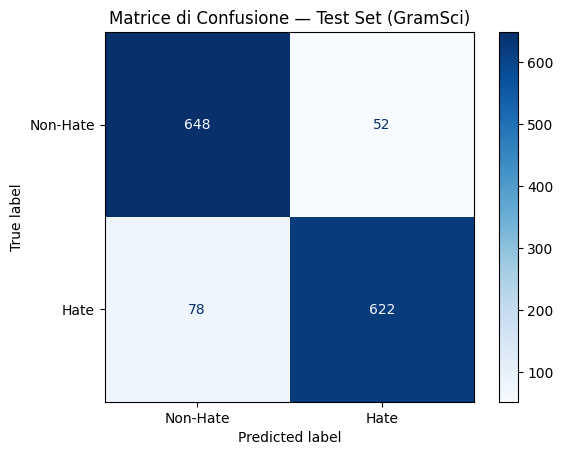

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm   = confusion_matrix(test_labels_arr, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Hate', 'Hate'])
disp.plot(cmap='Blues')
plt.title('Matrice di Confusione — Test Set (GramSci)')
plt.show()


## 12. Generazione predizioni e analisi degli errori

Salvo le predizioni finali e analizzo i casi più erroneamente classificati,
distinguendo falsi positivi (Non-Hate predetti come Hate) e falsi negativi
(Hate non rilevato, i più critici per il task).


In [ ]:
results_df = test_df[['anonymized_tweet_id', 'anonymized_text', 'label']].copy()
results_df['prediction'] = test_preds
results_df['confidence'] = test_probs
results_df['correct']    = (results_df['label'] == results_df['prediction']).astype(int)

results_df.to_csv('predictions_encoder_only.csv', index=False)
print('Predizioni salvate in predictions_encoder_only.csv')
print(f'\nAccuracy: {results_df["correct"].mean():.4f}')
print(results_df.head())


Predizioni salvate in predictions_encoder_only.csv

Accuracy: 0.9071
   anonymized_tweet_id                                    anonymized_text  \
0      424801448454884  questo anno #babbonatale portato giocattolo it...   
1      775194088981616  Adesso che in mezzo alla strada grazie al verg...   
2      386928936347190  Circondatevi di persone che non sono diventate...   
3      957546674360002  Seriamente, per capire, se un ladro mi entra i...   
4      530526299555950  Che poi è probabile che #Spataro non sia potut...   

   label  prediction  confidence  correct  
0      1           0    0.069635        0  
1      1           1    0.980758        1  
2      0           0    0.000605        1  
3      0           0    0.001903        1  
4      0           0    0.002359        1  


In [ ]:
# Falsi Positivi: predetti Hate, ma sono Non-Hate
fp = results_df[(results_df['label'] == 0) & (results_df['prediction'] == 1)].sort_values(
    'confidence', ascending=False)
print(f'Falsi Positivi: {len(fp)}')
print(fp[['anonymized_text', 'confidence']].head(3).to_string())

print()

# Falsi Negativi: predetti Non-Hate, ma contengono Hate (più critici per il task)
fn = results_df[(results_df['label'] == 1) & (results_df['prediction'] == 0)].sort_values(
    'confidence', ascending=True)
print(f'Falsi Negativi: {len(fn)}')
print(fn[['anonymized_text', 'confidence']].head(3).to_string())


Falsi Positivi: 52
                                                                                                                                                                                                                                                                            anonymized_text  confidence
938                                                                                                                                           #LaTtualità #Draghi #GovernoDraghi #SalviniPagliaccio #Salvini #riaperture #DecretoRiaperture #DecretoCovid #Coprifuoco aprire la foto! [URL]    0.998945
339  Mentre il leader del #cdx #salvinicitofona accade che nelle regioni da loro gestite, 5 vadano #esercizioprovvisorio, in #Sicilia viene pure bocciato ora è caos, mentre lui fa il coglione noi ci apprestiamo a pagare le conseguenze della loro incapacità\n#22gennaio #salvini #Lega    0.998846
336                                                                                          